# MICrONS Functional Dataset Exploration

This notebook explores the functional dataset while keeping the same structural context used in the basic tutorial.

Main goals:
- Load structural units and functional coregistration information
- Explore trial-level neural responses
- Inspect stimulus metadata for a selected trial
- Build a small structure-function summary

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

In [2]:
cleaner = mic.MicronsDataCleaner(datadir='data', version=1718, download_policy='minimum')

# Build structural units with functional matching info.
units_match, segments = cleaner.process_nucleus_data(functional_data='match')

print(f'Units table shape: {units_match.shape}')
print(f'Segments table shape: {segments.shape}')
units_match.head()

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 90678.76it/s]


Units table shape: (94167, 15)
Segments table shape: (5, 5)


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,functional_unit_id,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,not_matched,L5
3,200523,864691135777840480,513.635721,509.463386,652.56,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,not_matched,L6
4,372649,864691136273924109,829.039163,557.615841,1039.92,excitatory_neuron,6P-IT,V1,none,none,NaN,NaN,NaN,not_matched,L6


In [11]:
matched = fl.filter_neurons(units_match, tuning='matched').copy()
not_matched = units_match[units_match['tuning_type'] != 'matched'].copy()

print(f"Matched neurons: {len(matched)}")
print(f"Not matched neurons: {len(not_matched)}")

summary = pd.Series({
    'n_rows_units_match': len(units_match),
    'n_rows_matched': len(matched),
    'n_rows_not_matched': len(not_matched),
    'n_unique_nucleus_ids_matched': matched['nucleus_id'].nunique(),
    'n_unique_sessions': matched['session'].nunique(),
    'n_unique_scans': matched[['session', 'scan_idx']].drop_duplicates().shape[0],
})
summary

Matched neurons: 19077
Not matched neurons: 75090


n_rows_units_match              94167
n_rows_matched                  19077
n_rows_not_matched              75090
n_unique_nucleus_ids_matched    15344
n_unique_sessions                   6
n_unique_scans                     16
dtype: int64

In [4]:
# Top anatomical groups among matched neurons.
matched.groupby(['brain_area', 'layer'], dropna=False).size().sort_values(ascending=False).head(20)

brain_area  layer
V1          L2/3     6345
            L4       3945
            L5       2325
RL          L2/3     2211
            L4       1559
            L5        795
AL          L2/3      535
V1          L6        486
AL          L4        409
            L5        228
RL          L6        151
AL          L6         41
V1          L1         16
LM          L2/3       13
RL          L1          7
LM          L4          5
            L5          5
            L6          1
dtype: int64

In [5]:
# Try common functional H5 locations used in this workspace.
candidate_paths = [
    Path('data/functional/microns_functional.h5'),
    Path('data/functional/microns_functional.h5.h5'),
    Path('neuroscience-project/tommy/microns.h5'),
]

existing = [p for p in candidate_paths if p.exists()]
if len(existing) == 0:
    raise FileNotFoundError(
        'No functional H5 file found. Expected one of: ' + ', '.join(str(p) for p in candidate_paths)
    )

functional_path = existing[0]
print(f'Using functional H5 file: {functional_path}')

funcreader = mic.MicronsFunctionalReader(datadir='data', path=str(functional_path))

Using functional H5 file: data\functional\microns_functional.h5


Keys: ['session', 'trial_idx', 'responses', 'treadmill', 'pupil', 'stim_times']
responses shape: (5312, 75)
stim_times shape: (75,)


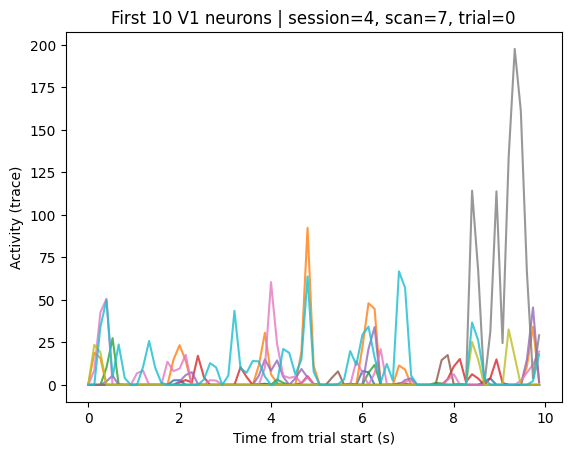

In [7]:
# Pick one valid (session, scan) directly from matched units.
example = matched[['session', 'scan_idx']].dropna().drop_duplicates().iloc[0]
session = int(example['session'])
scan_idx = int(example['scan_idx'])
trial = 0
sesh_scan = f'{session}_{scan_idx}'

responses_dict = funcreader.get_trial(sesh_scan, trial, brain_area='V1')

print('Keys:', list(responses_dict.keys()))
print('responses shape:', responses_dict['responses'].shape)
print('stim_times shape:', responses_dict['stim_times'].shape)

time = responses_dict['stim_times'] - responses_dict['stim_times'][0]
n_plot = min(10, responses_dict['responses'].shape[0])
for i in range(n_plot):
    plt.plot(time, responses_dict['responses'][i, :], alpha=0.8)

plt.xlabel('Time from trial start (s)')
plt.ylabel('Activity (trace)')
plt.title(f'First {n_plot} V1 neurons | session={session}, scan={scan_idx}, trial={trial}')
plt.show()

In [8]:
# Read stimulus metadata for this trial.
hashes = funcreader.get_hashes_by_session(sesh_scan)
trial_hash = hashes[trial]
h_key = trial_hash.replace('/', '%2F')
vid_grp = funcreader.f[f'videos/{h_key}']

videoprops = {'clip': vid_grp['clip'][:]}
if 'times' in vid_grp:
    videoprops['times'] = vid_grp['times'][:]
else:
    videoprops['times'] = time

for key in ['directions', 'onsets']:
    if key in vid_grp:
        videoprops[key] = vid_grp[key][:]

for attr_key in vid_grp.attrs.keys():
    videoprops[attr_key] = vid_grp.attrs[attr_key]

print('Stimulus metadata keys:', sorted(videoprops.keys()))
pd.Series({k: type(v).__name__ for k, v in videoprops.items()}).sort_index()

Stimulus metadata keys: ['clip', 'duration', 'fps', 'movie_name', 'original_hash', 'short_movie_name', 'times', 'type']


clip                ndarray
duration            float64
fps                 float64
movie_name              str
original_hash           str
short_movie_name        str
times               ndarray
type                    str
dtype: object

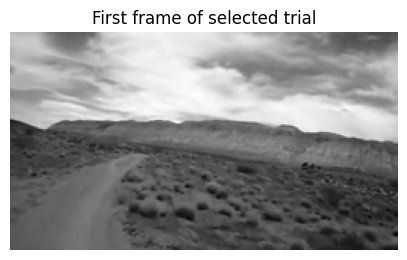

This trial has no direction/onset metadata (likely not a Monet trial).


In [9]:
# Visualize first frame and, when available, direction switches.
plt.figure(figsize=(5, 5))
plt.imshow(videoprops['clip'][0, :, :], cmap='gray')
plt.title('First frame of selected trial')
plt.axis('off')
plt.show()

if 'directions' in videoprops and 'onsets' in videoprops:
    dt = time[1] - time[0]
    idx_change = np.round(videoprops['onsets'] / dt).astype(int)
    print('Directions:', videoprops['directions'])
    print('Onsets (s):', videoprops['onsets'])
    print('Frame indices of direction changes:', idx_change)
else:
    print('This trial has no direction/onset metadata (likely not a Monet trial).')

In [10]:
# Small structure-function summary from the same structural units.
units_best, _ = cleaner.process_nucleus_data(functional_data='best_only')
units_best_matched = fl.filter_neurons(units_best, tuning='matched').copy()

if 'rate_ori' in units_best_matched.columns and len(units_best_matched) > 0:
    rates = np.reshape(np.concatenate(units_best_matched['rate_ori'].values), (-1, 8))
    mean_rate_by_orientation = rates.mean(axis=0)
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(8), mean_rate_by_orientation, marker='o')
    plt.xticks(np.arange(8), [0, 45, 90, 135, 180, 225, 270, 315])
    plt.xlabel('Orientation (deg)')
    plt.ylabel('Mean response')
    plt.title('Population mean tuning curve (matched neurons)')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print('rate_ori not available in this table version.')

units_best_matched[['nucleus_id', 'pt_root_id', 'brain_area', 'layer']].head()

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 92393.79it/s]


rate_ori not available in this table version.


,nucleus_id,pt_root_id,brain_area,layer
16,189115,864691135738006641,V1,L2/3
20,153275,864691135463256477,V1,L2/3
21,153085,864691135748985641,V1,L2/3
34,363874,864691135699950114,V1,L4
36,362609,864691136126239014,V1,L4
